# EXPLORACIÓN Y ANÁLISIS DE DATOS

In [1]:
# Importación de librerias

import pandas as pd
from cargar_datos import cargarDatos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Cargue de datos desde script cargar_datos
df = cargarDatos()
df

       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35         3692160.0           10   
1                 4 2025-04-22 09:47:35          840000.0            6   
2                 9 2026-01-08 12:22:40         5974028.4           10   
3                 4 2025-08-04 12:04:10         1671240.0            6   
4                 9 2025-04-26 11:24:26         2781636.0           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28         2414886.0           10   
10759             4 2025-01-10 16:40:21         2916000.0           24   
10760             4 2025-06-19 14:28:47         4249200.0           36   
10761             9 2025-03-02 11:53:41         1283307.6           10   
10762             4 2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independient

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,9,2025-01-19 16:18:28,2414886.0,10,29,Independiente,3000000,300000,204819,13.134355,...,172.0,1112.0,1112.0,NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,2916000.0,24,27,Empleado,2500000,400000,127460,55.973342,...,0.0,9771.0,9771.0,0.0,1,0,4,1958333.0,Creciente,0
10760,4,2025-06-19 14:28:47,4249200.0,36,24,Empleado,2000000,500000,140042,47.613894,...,0.0,1603.0,1603.0,0.0,1,0,0,998859.0,Creciente,0
10761,9,2025-03-02 11:53:41,1283307.6,10,26,Empleado,1500000,600000,108958,42.888527,...,0.0,8488.0,8488.0,0.0,2,0,3,NaN,NaN,0


# Información general y valores nulos 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

# Verificación y limpieza de tipo de datos

## Edad
Se identificaron 150 registros con edades mayores a 120 años, adicionalmente se analizan las demás variables y se encuentran incosistencias como que se tienen valores muy altos en la variable "Total_otros_prestamos" pero se tienen puntajes de 0 en datacrédito, los valores de saldo total y saldo principal se encuentran vacios y el número de creditos en todos los sectores es 0, teniendo en cuenta que estos registros representan el 1.4% del total, se opta por eliminarlos para evitar introducir ruido e incertidumbre a los modelos de predicción.

In [4]:
edad_mayores=df[df['edad_cliente'] > 69]
edad_mayores

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
7008,9,2025-07-13 16:02:38,8153115.6,5,122,Empleado,38062010,20671524,1323066,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7009,9,2025-04-16 17:06:52,5507376.0,5,122,Empleado,125078024,15138472,893982,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7010,9,2025-05-24 15:22:58,8020394.4,10,122,Empleado,9858473,1178318,682754,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7011,9,2025-04-12 10:34:46,9138667.2,9,122,Empleado,200000000,6000000,854698,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7012,9,2025-03-21 12:36:10,4820638.8,9,122,Empleado,5680147,18704,449775,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7153,9,2025-06-14 18:40:01,8005700.4,10,122,Empleado,105912527,75500000,681503,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7154,9,2025-02-21 15:31:25,976728.0,9,122,Empleado,50000000,0,91305,-16.250449,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,0
7155,9,2025-05-30 15:38:55,6613239.6,9,122,Empleado,970534000,0,619690,91.728786,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1
7156,4,2025-05-04 16:05:39,9216000.0,6,122,Empleado,300000000,0,1373478,95.227787,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,1


In [5]:
df = df[df['edad_cliente']<=69].copy()
df

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,9,2025-01-19 16:18:28,2414886.0,10,29,Independiente,3000000,300000,204819,13.134355,...,172.0,1112.0,1112.0,NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,2916000.0,24,27,Empleado,2500000,400000,127460,55.973342,...,0.0,9771.0,9771.0,0.0,1,0,4,1958333.0,Creciente,0
10760,4,2025-06-19 14:28:47,4249200.0,36,24,Empleado,2000000,500000,140042,47.613894,...,0.0,1603.0,1603.0,0.0,1,0,0,998859.0,Creciente,0
10761,9,2025-03-02 11:53:41,1283307.6,10,26,Empleado,1500000,600000,108958,42.888527,...,0.0,8488.0,8488.0,0.0,2,0,3,NaN,NaN,0


## Tendencia Ingresos
Se identificaron registros numéricos en la variable categórica, se aplica una función de limpieza dejando vacíos los datos que contienen valores numéricos


In [6]:
# Verificación datos en columna Tendencia_ingresos
print(df['tendencia_ingresos'].unique())
df['tendencia_ingresos'] = df['tendencia_ingresos'].astype(str)
# Se observan valores numéricos y de texto por lo que se realiza la siguiente función de limpieza para eliminar datos numéricos
def limpiar_tendencia(valor):
    try:
        float(valor)  # intenta convertir a número
        return np.nan  # si lo logra, reemplaza por NaN (vacío)
    except ValueError:
        return valor  # si falla, deja el texto original
# aplicar función a columna 
df['tendencia_ingresos'] = df['tendencia_ingresos'].apply(limpiar_tendencia)

# Verificación limpieza de datos
print(df['tendencia_ingresos'].unique())

['Estable' 'Creciente' nan 'Decreciente' 8315 0 158042 3978 9147 168750
 -28589 1000000 -566272 24702 31837 122727 417087 9090 173031 -70715
 -435177 -702927 -4105 54683 22832 209090 5697 10808 -288 -164315 2029000
 17181 15245 82657 52862 1817052 75761 146918 1123000 15090 4250635 22363
 -101368 86286 65988 77975 -224714]
['Estable' 'Creciente' nan 'Decreciente']


# Tipo de Credito
Se identificó un registro con tipo de crédito 68, se opta por corregir este valor por la moda de la variable "tipo_credito"



In [7]:
moda_tipo_cred = df['tipo_credito'].mode()

In [8]:
df['tipo_credito'] = df['tipo_credito'].apply(lambda x: moda_tipo_cred  if x == 68 else x )

In [9]:
df['tipo_credito'] = df['tipo_credito'].astype(int)

C:\Users\mar_o\AppData\Local\Temp\ipykernel_20964\932176161.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df['tipo_credito'] = df['tipo_credito'].astype(int)


## Salario Cliente
Se identificaron algunos registros con valores 0, se va aplicar una función de limpieza para dejar estos valores como nulos.

In [10]:
def limpieza_salario(valor):
    if valor ==0:
        return None
    else:
        return valor

In [11]:
df['salario_cliente'] = df['salario_cliente'].apply(limpieza_salario)

## Puntaje y Puntaje_datacredito

In [12]:
# Se asigna dato nulo a puntajes negativos o iguales a 0
df['puntaje'] = df['puntaje'].apply(lambda x: None if x <= 0 else x)


In [13]:
# se realiza la misma limpieza para la variable puntaje_datacredito
df['puntaje_datacredito'] = df['puntaje_datacredito'].apply(lambda x: None if x<=0 else x)

# Validación de consistencia de datos

In [14]:
# Valido si existen saldos principales mayores al saldo total
valid_saldos=df[df['saldo_total']-df['saldo_principal']<0]
print(valid_saldos)


Empty DataFrame
Columns: [tipo_credito, fecha_prestamo, capital_prestado, plazo_meses, edad_cliente, tipo_laboral, salario_cliente, total_otros_prestamos, cuota_pactada, puntaje, puntaje_datacredito, cant_creditosvigentes, huella_consulta, saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal, promedio_ingresos_datacredito, tendencia_ingresos, Pago_atiempo]
Index: []

[0 rows x 23 columns]


## Valores Nulos

In [15]:
# Información general
print("\n Información del Dataset:")
print(f"Número de registros: {len(df)}")
print(f"Número de variables: {len(df.columns)}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())


 Información del Dataset:
Número de registros: 10613
Número de variables: 23

Valores nulos por columna:
tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                    24
total_otros_prestamos               0
cuota_pactada                       0
puntaje                           130
puntaje_datacredito                 4
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                          7
saldo_total                         7
saldo_principal                   256
saldo_mora_codeudor               440
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2780
tendencia_ingresos               2840
Pago_atiempo                        0
dtype: int64


## Duplicados

In [16]:
df.duplicated().sum()

np.int64(0)

# Estadística Descriptiva

In [17]:
df.describe()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10613.000000,10613,1.061300e+04,10613.000000,10613.000000,1.058900e+04,1.061300e+04,1.061300e+04,10483.000000,10609.000000,...,10613.000000,10606.000000,1.060600e+04,1.035700e+04,10173.000000,10613.000000,10613.000000,10613.000000,7.833000e+03,10613.000000
mean,5.355319,2025-04-16 14:43:03.877697024,2.386180e+06,10.601338,42.845661,7.713191e+06,1.680308e+06,2.384975e+05,92.482253,791.540107,...,4.288326,6.773053,4.594077e+04,4.034907e+04,0.260002,2.818996,0.273627,1.321116,2.005157e+06,0.952888
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,1.000000e+03,0.000000e+00,2.394400e+04,0.050943,7.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 13:50:13,1.215240e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.205250e+05,95.227787,758.000000,...,2.000000,0.000000,2.897500e+03,2.689000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 09:55:36,1.903680e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.811400e+05,95.227787,792.000000,...,4.000000,0.000000,1.618550e+04,1.444300e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 09:32:42,3.042358e+06,12.000000,52.000000,4.660000e+06,2.000000e+06,2.828620e+05,95.227787,826.000000,...,6.000000,0.000000,5.298800e+04,4.764500e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,10.000000,2026-04-26 18:43:52,2.880000e+07,90.000000,69.000000,2.200000e+10,1.500000e+09,2.671342e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.234447,NaN,1.766575e+06,6.669887,11.947307,2.702834e+08,1.496717e+07,1.977364e+05,11.786963,51.436014,...,3.044458,202.529937,1.062742e+05,7.124527e+04,21.772917,2.748218,0.720793,1.830646,2.144116e+06,0.211888


# Análisis Univariable 

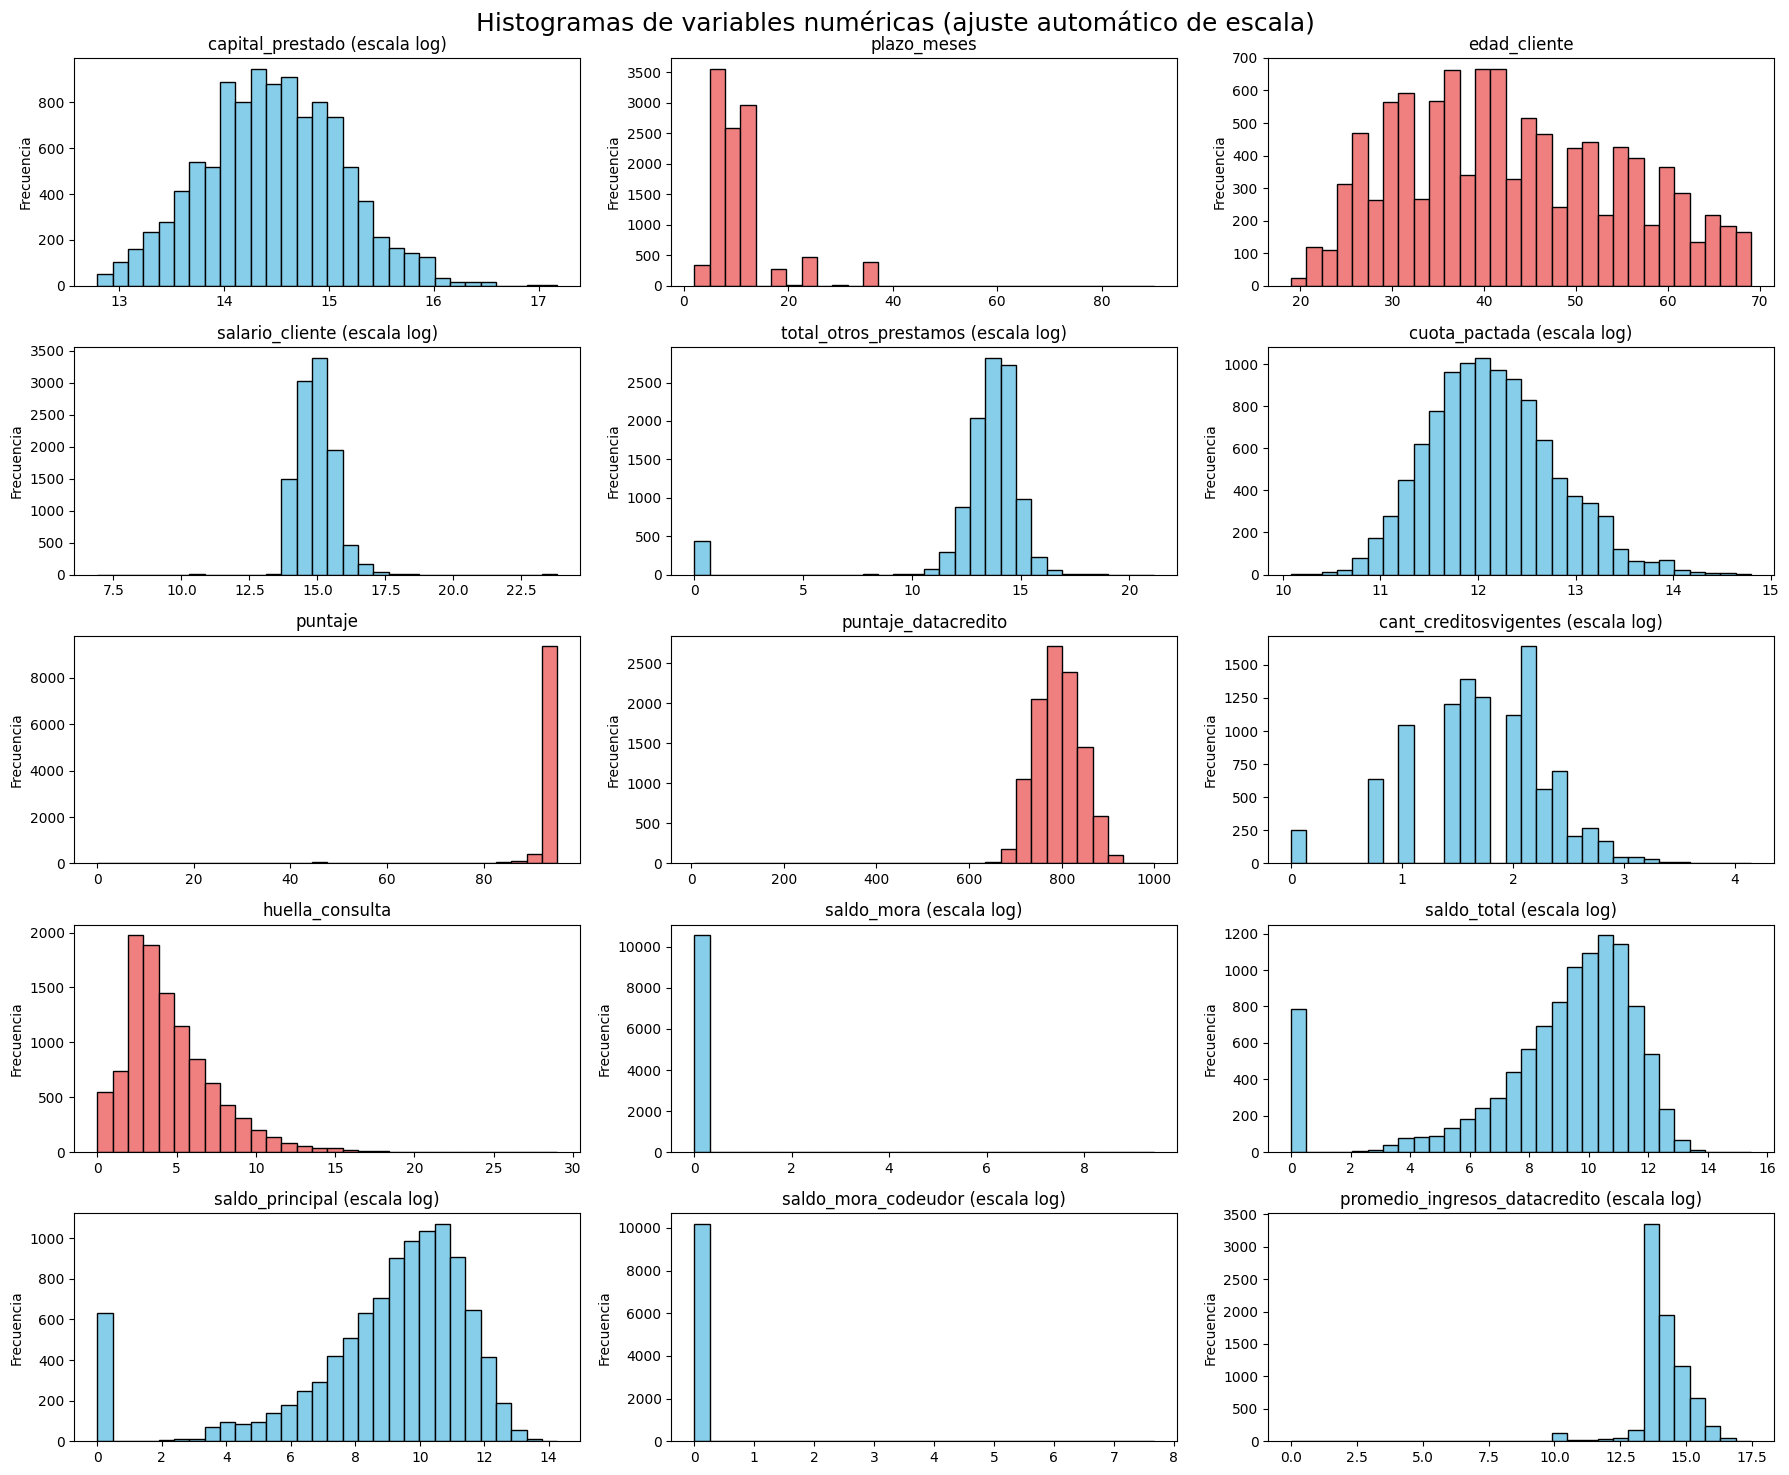

In [18]:
# Graficos con variables 
# Lista de variables numéricas
num_vars = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
    'saldo_principal', 'saldo_mora_codeudor', 'promedio_ingresos_datacredito'
]

# Crear grid de subplots
fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    data = df[col].dropna()
    
    # Condición para aplicar log: valores muy grandes comparados con la mediana
    if data.max() > data.median() * 10:
        data = np.log1p(data)  # log(1+x) evita problemas con ceros
        axes[i].hist(data, bins=30, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{col} (escala log)')
    else:
        axes[i].hist(data, bins=30, color='lightcoral', edgecolor='black')
        axes[i].set_title(col)
    
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Histogramas de variables numéricas (ajuste automático de escala)", fontsize=18)
plt.tight_layout()
plt.show()

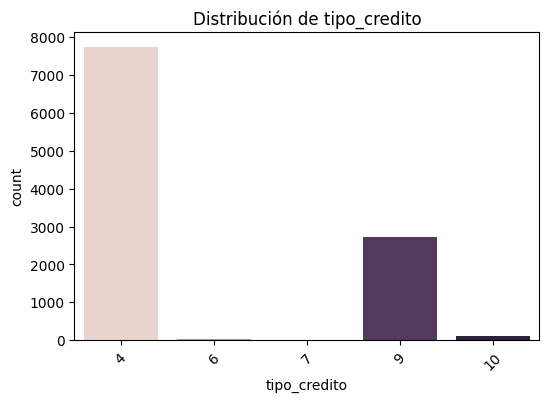

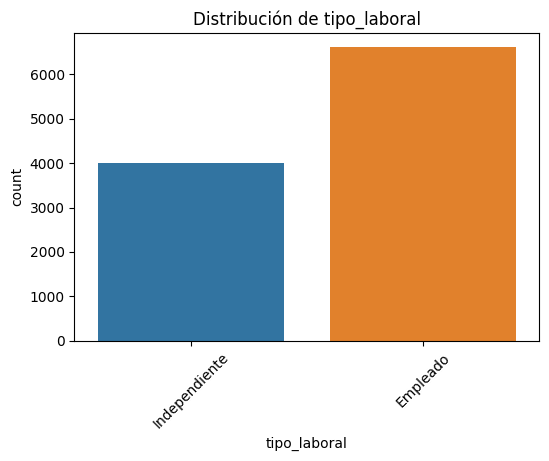

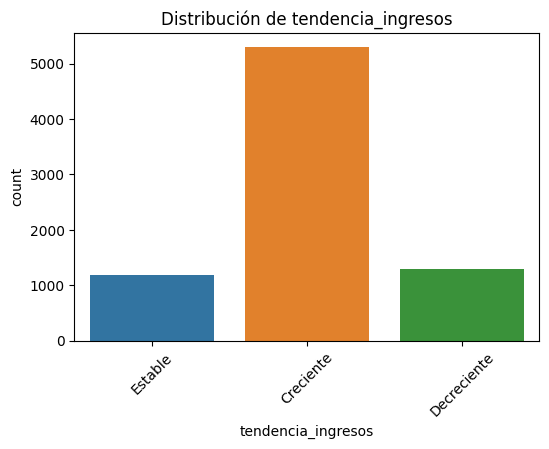

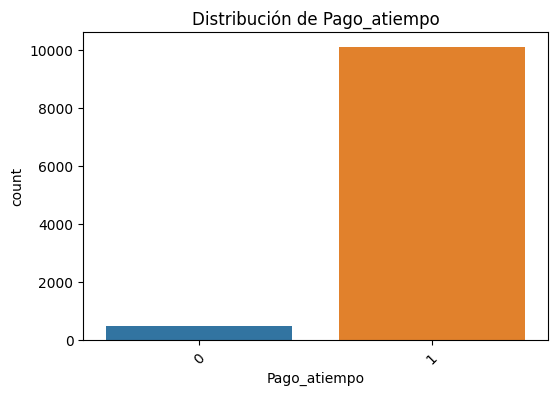

In [19]:
# Graficas Bar plot para Var. Categóricas
import seaborn as sns

cat_vars = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

for col in cat_vars:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, hue=col,legend=False)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()

In [28]:
df['Pago_atiempo'].value_counts(normalize=True)

Pago_atiempo
1    0.952888
0    0.047112
Name: proportion, dtype: float64

# Análisis Bivariable


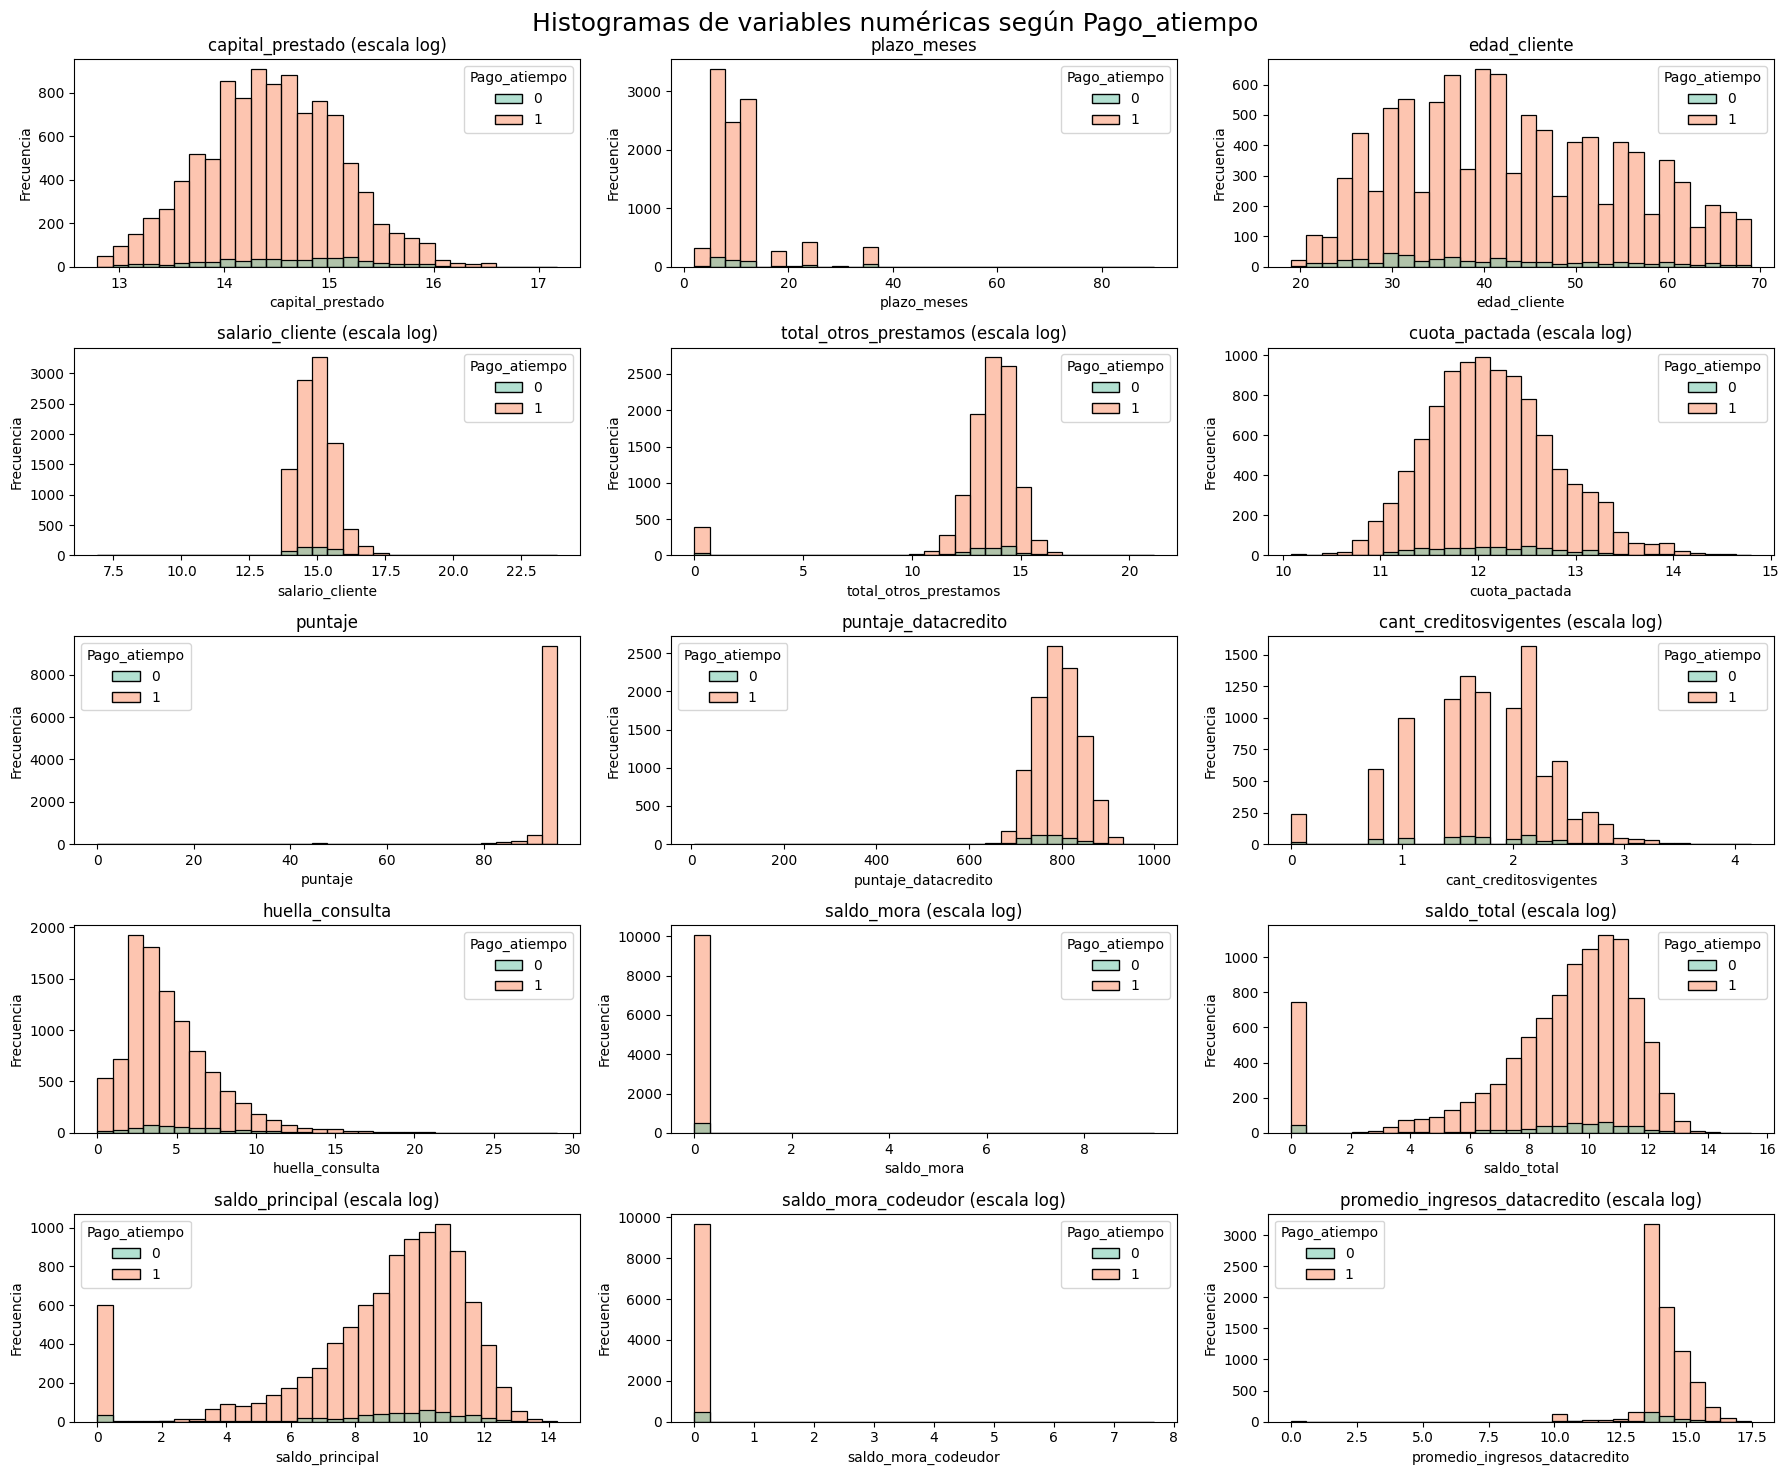

In [20]:
# Análisis con variables numéricas
# Lista de variables numéricas
num_vars = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
    'saldo_principal', 'saldo_mora_codeudor', 'promedio_ingresos_datacredito'
]

# Crear grid de subplots
fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    data = df[col].dropna()
    
    # Condición para aplicar log: valores muy grandes comparados con la mediana
    if data.max() > data.median() * 10:
        data = np.log1p(data)  # log(1+x) evita problemas con ceros
        sns.histplot(x=data, hue=df.loc[data.index, 'Pago_atiempo'],
                     bins=30, kde=False, palette='Set2', ax=axes[i])
        axes[i].set_title(f'{col} (escala log)')
    else:
        sns.histplot(x=data, hue=df.loc[data.index, 'Pago_atiempo'],
                     bins=30, kde=False, palette='Set2', ax=axes[i])
        axes[i].set_title(col)
    
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Histogramas de variables numéricas según Pago_atiempo", fontsize=18)
plt.tight_layout()
plt.show()

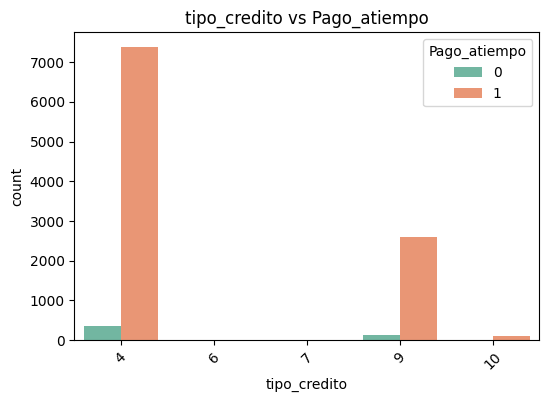

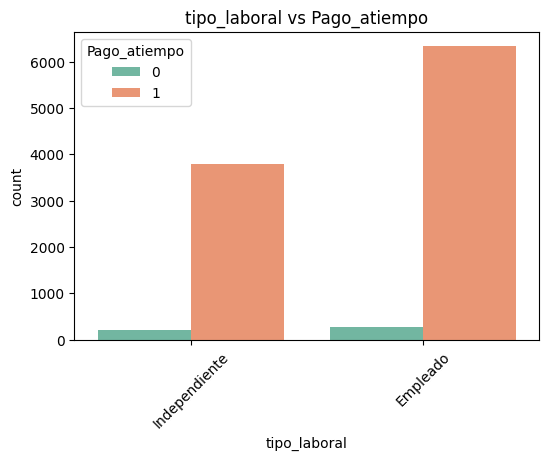

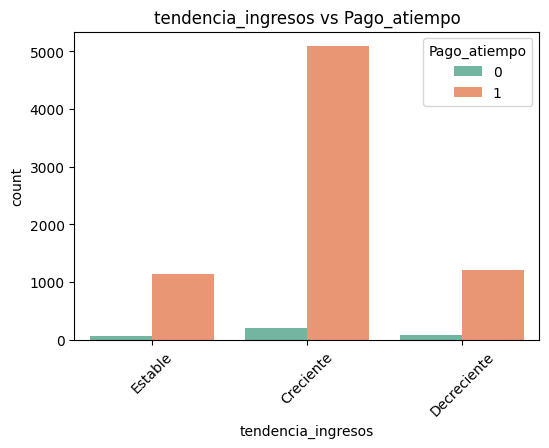

In [21]:
# Graficos con Variables Categóricas
cat_vars = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']

for col in cat_vars:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Pago_atiempo', data=df, palette='Set2')
    plt.title(f'{col} vs Pago_atiempo')
    plt.xticks(rotation=45)
    plt.show()


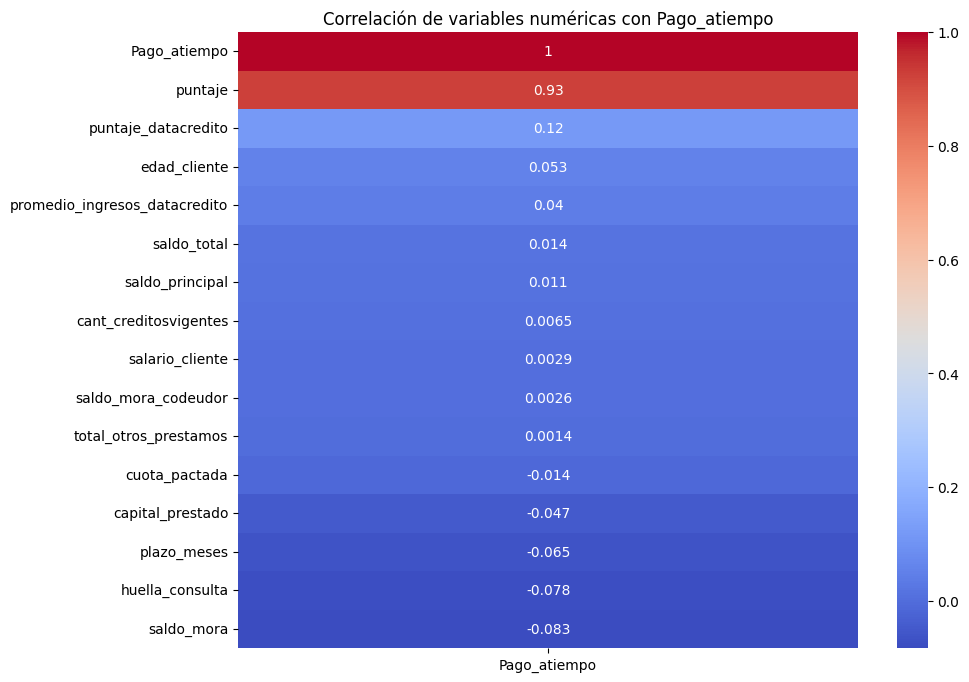

In [22]:
corr = df[num_vars + ['Pago_atiempo']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr[['Pago_atiempo']].sort_values(by='Pago_atiempo', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlación de variables numéricas con Pago_atiempo")
plt.show()


# ANÁLISIS MULTIVARIABLE


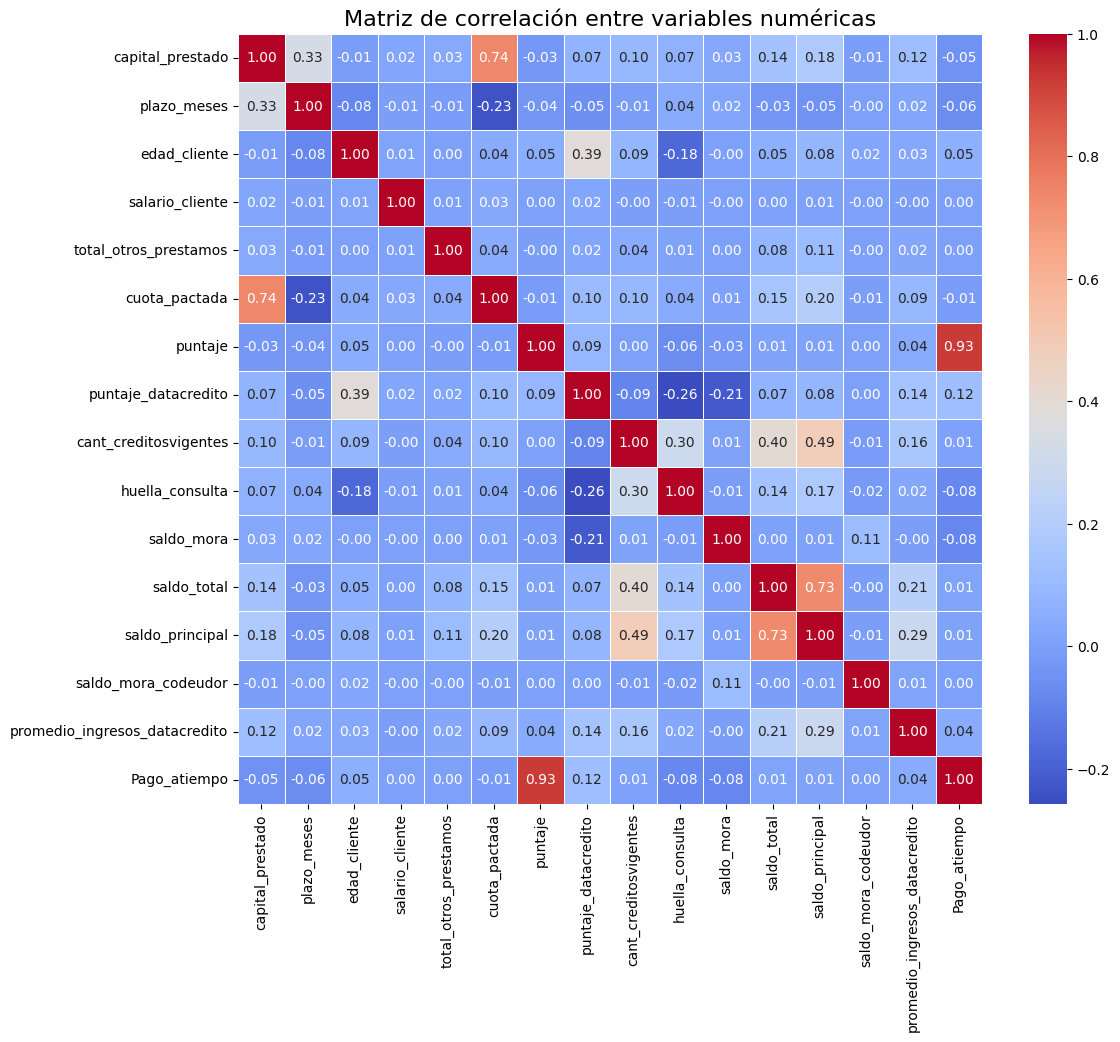

In [23]:
# Seleccionar solo variables numéricas + objetivo
num_vars = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
    'saldo_principal', 'saldo_mora_codeudor', 'promedio_ingresos_datacredito',
    'Pago_atiempo'
]

# Calcular correlación
corr = df[num_vars].corr()

# Graficar matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas", fontsize=16)
plt.show()

Se observa una alta correlación de 0.74 y 0.73 entre las variables cuota pactada y capital_prestado y saldo_total-saldo_principal respectivamente, por lo que para la construcción del modelo se tendrán en cuenta el capital_prestado y el saldo_total para evitar multicolinealidad en el modelo. Por otro lado se observa que la variable con mayor correlación con la variable objetivo es puntaje.

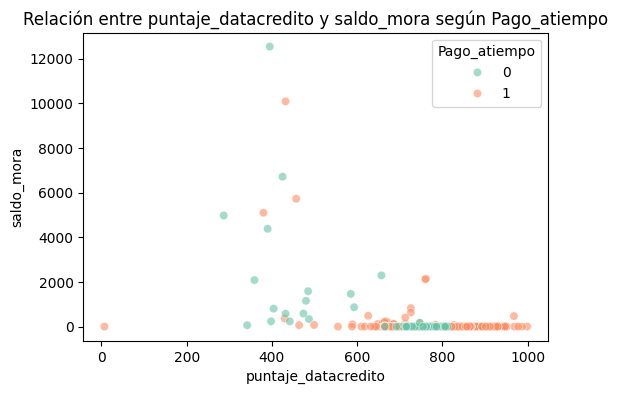

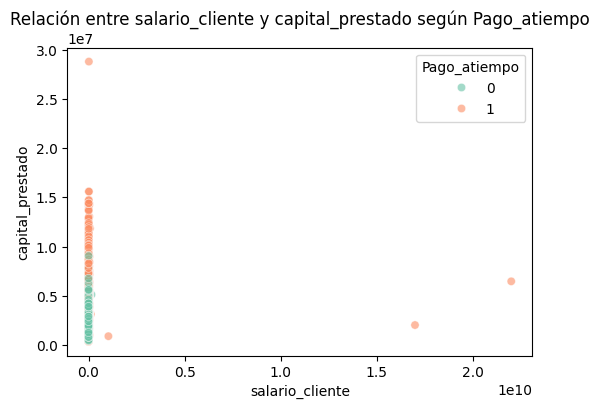

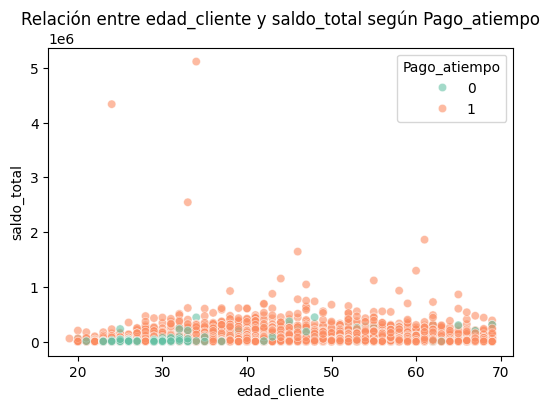

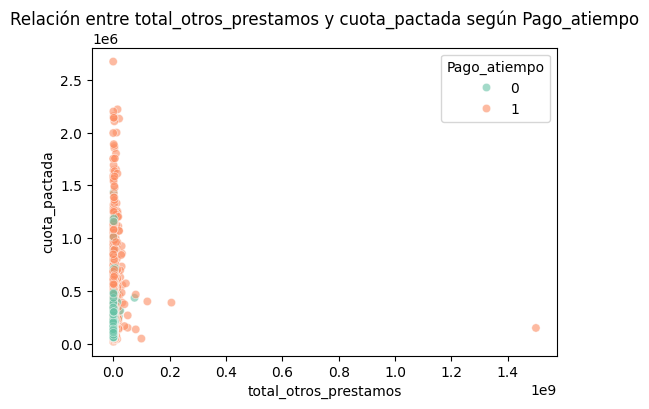

In [24]:
# Gráficas de dispersión
pairs = [
    ('puntaje_datacredito', 'saldo_mora'),
    ('salario_cliente', 'capital_prestado'),
    ('edad_cliente', 'saldo_total'),
    ('total_otros_prestamos', 'cuota_pactada')
]

for x, y in pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y, hue='Pago_atiempo', palette='Set2', alpha=0.6)
    plt.title(f"Relación entre {x} y {y} según Pago_atiempo")
    plt.show()


In [25]:
df.columns.values

array(['tipo_credito', 'fecha_prestamo', 'capital_prestado',
       'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente',
       'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal',
       'saldo_mora_codeudor', 'creditos_sectorFinanciero',
       'creditos_sectorCooperativo', 'creditos_sectorReal',
       'promedio_ingresos_datacredito', 'tendencia_ingresos',
       'Pago_atiempo'], dtype=object)

En el df final limpio no voy a tener en cuenta 'puntaje' ya que tiene una correlación muy alta con la variable target

In [ ]:
df_limpio = df[['tipo_credito', 'capital_prestado',
       'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente',
       'total_otros_prestamos',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total',
       'saldo_mora_codeudor', 'creditos_sectorFinanciero',
       'creditos_sectorCooperativo', 'creditos_sectorReal', 'tendencia_ingresos',
       'Pago_atiempo']]

In [30]:
# Guardar el DataFrame limpio
df_limpio.to_excel("df_limpio.xlsx")
print(" DataFrame limpio guardado en df_limpio")

 DataFrame limpio guardado en df_limpio
